# Credit Risk Scoring

Imports

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
import warnings

In [8]:
warnings.filterwarnings("ignore")

Lectura de datos

In [17]:
df = pd.read_csv("../data/raw/cs-training.csv", index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [18]:
print(f"El dataframe tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataframe tiene 150000 filas y 11 columnas.


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [28]:
df.isna().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [35]:
cols_con_nulos = ["MonthlyIncome", "NumberOfDependents"]
print("Nulos:")
for col in cols_con_nulos:
    print(f'{col}: {df[col].isna().sum() *100/ df[col].shape[0]:.2f}%')

Nulos:
MonthlyIncome: 19.82%
NumberOfDependents: 2.62%


La columna *MonthlyIncome* tiene casi un 20% de nulos.

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


Errores:
- Máximos fuera de rango:
    * RevolvingUtilizatinoOfUnsecuredLines: Debería ir entre 0 y 1.
    * DebtRatio
- Valores outliers o a investigar:
    * MonthlyIncome
    * NumberOfOpenCreditLinesAndLoans
    * NumberOfTimes90DaysLate
    * NumberRealEstateLoansOrLines
    * NumberOfTimes60-89DaysPastDueNotWorse
    * NumberOfDependents


Esperamos un claro desbalanceo de clases:

In [40]:
df.SeriousDlqin2yrs.value_counts(normalize=True)*100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

Text(0, 0.5, 'total')

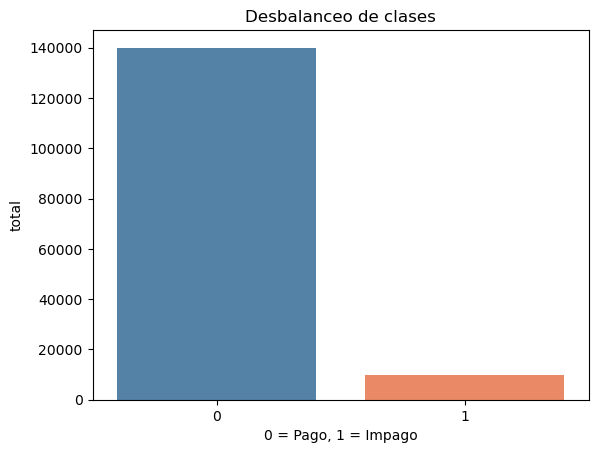

In [64]:
sns.countplot(data=df, x="SeriousDlqin2yrs", palette=['steelblue', 'coral'])
plt.title("Desbalanceo de clases")
plt.xlabel("0 = Pago, 1 = Impago")
plt.ylabel("total")


Repasamos los errores y problemas que hemos visto antes:

Distribuciones de las variables numéricas

*Age*

<Axes: xlabel='age', ylabel='Count'>

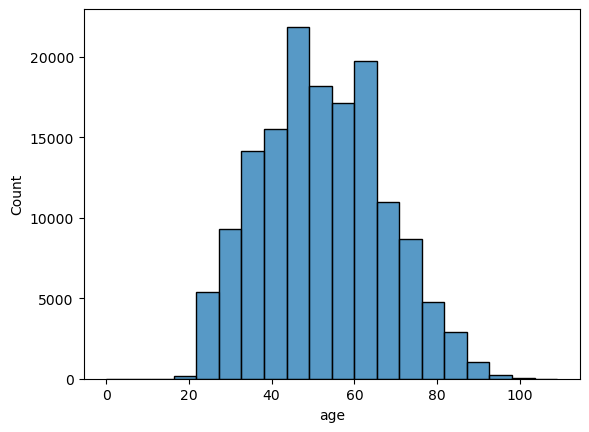

In [66]:
sns.histplot(data = df, x="age", bins=20)

El mínimo de la variable edad era = 0:

In [67]:
df[df.age == 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


Al ser un solo registro con edad = 0, lo eliminamos de los datos:

<Axes: xlabel='age', ylabel='Count'>

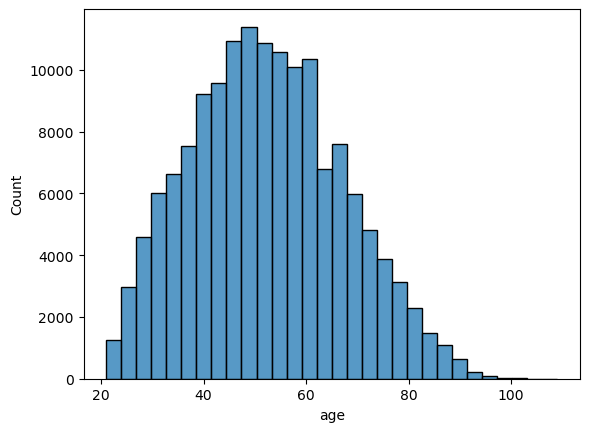

In [87]:
df = df[df.age != 0]
sns.histplot(data=df, x="age", bins=30)



*RevolvingUtilizationOfUnsecuredLines*

<Axes: xlabel='RevolvingUtilizationOfUnsecuredLines', ylabel='Count'>

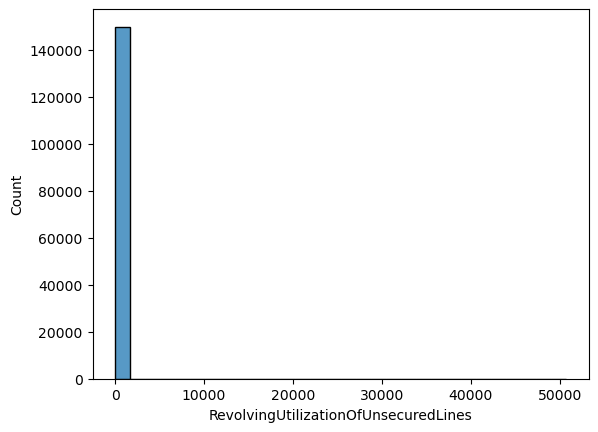

In [72]:
sns.histplot(data = df, x ="RevolvingUtilizationOfUnsecuredLines", bins = 30)

Debido a los outliers, no vemos la distribución, que debería ir entre 0 y 1 aproximadamente (Podría haber personas que estén rebasando sus límites, por lo que pueden ser > 1)

Filtramos el dataset para valores menores a 2 para poder ver su distribución.

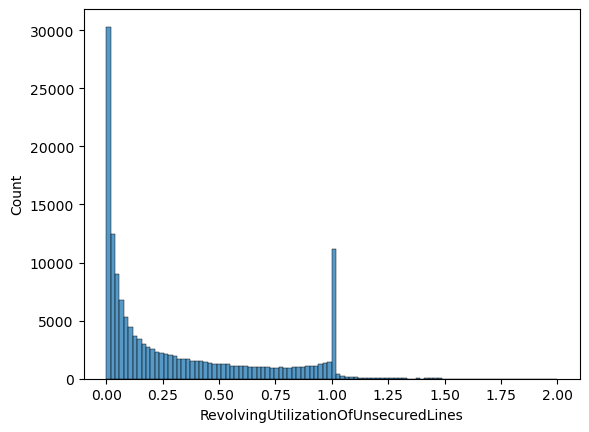

In [79]:
filtro = df.RevolvingUtilizationOfUnsecuredLines < 2
sns.histplot(data = df[filtro], x = "RevolvingUtilizationOfUnsecuredLines");

Vemos la gran mayoría de personas tienen una tasa de utilización cercana a 0, pero con un repunte en la tasa de utilización del 100%.

*DebtRatio*

<Axes: xlabel='DebtRatio', ylabel='Count'>

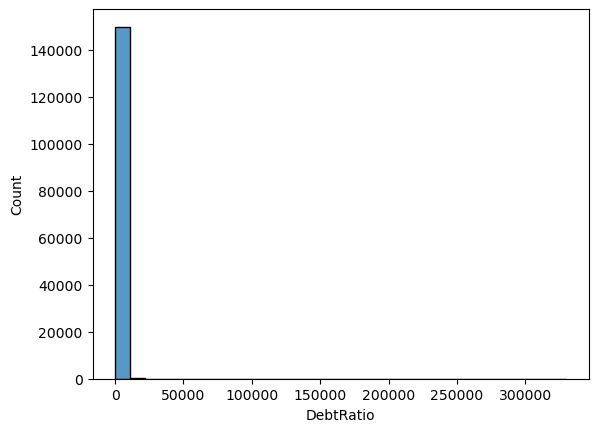

In [76]:
sns.histplot(data=df, x="DebtRatio", bins=30)

Mismo caso que el anterior. Filtramos estos datos por debajo de 2 para ver su distribución sin outliers:

<Axes: xlabel='DebtRatio', ylabel='Count'>

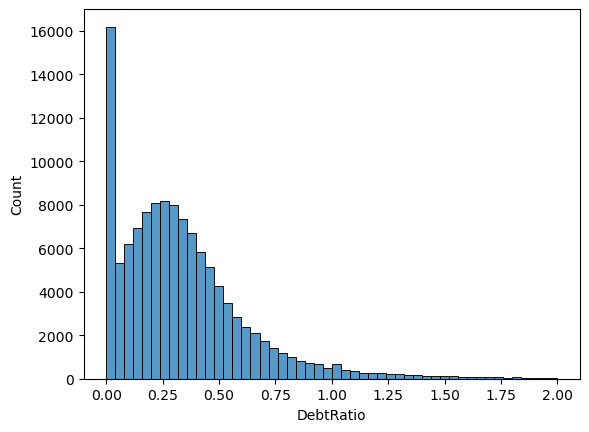

In [109]:
filtro = df.DebtRatio < 2
sns.histplot(data=df[filtro], x="DebtRatio", bins=50)

Muchas personas con 0, donde el resto se centra en un 25% de DebtRatio.

*MonthlyIncome*

Aquí tenemos que recordar que tenemos un 20% de nulos

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

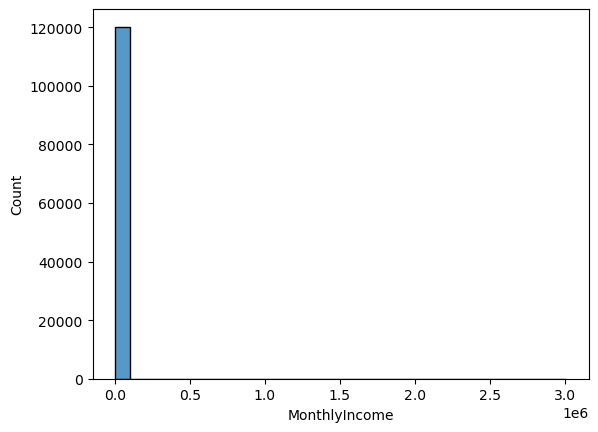

In [85]:
sns.histplot(data=df, x="MonthlyIncome", bins=30)


<Axes: xlabel='MonthlyIncome', ylabel='Count'>

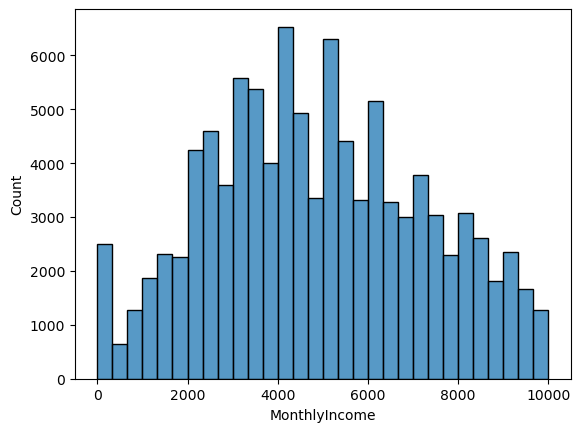

In [86]:
filtro = df.MonthlyIncome < 10_000
sns.histplot(data=df[filtro], x = "MonthlyIncome", bins = 30)

##### Resumen del EDA por ahora:

- Desbalanceo de clases: Tenemos un 93.3% de registros que pagaron , y solo un 6,7% que hicieron impago. Habrá que tenerlo en cuenta a la hora de modelizar. 
- Age: Eliminado un registro con edad = 0. También hay personas con edades mayores a 100 años, que decidimos mantener.
- RevolvingUtilizationOfUnsecuredLines, DebtRatio y MonthlyIncome: Outliers que impiden ver las distribuciones. Sin tener en cuenta esos outliers:
    - RevolvingUtilizationOfUnsecuredLines se centra en valores de cero o cercanos, con un claro repunte en 1 o una utilización del 100%.
    - DebtRatio: la mayoría están en 0, pero el resto sigue una distribución con forma de campana centrada en 25%.
    - MonthlyIncome: Distribución potencialmente normal, aunque con muchos valores = 0, que podrían ser estudiantes, pensionistas o personas en desempleo.
- Missing Values:
    - MonthlyIncome: Cerca de un 20% de estos valores son missings. Será crítico imputarlos correctamente.
    - NumberOfDependents: Un 2.6% de missings. Aquí no es tan importante ya que tendrá un impacto menor.

#### Matriz de correlaciones

Usamos los valores absolutos de las correlaciones para ver qué variables pesan más sobre nuestra variable objetivo.

<Axes: >

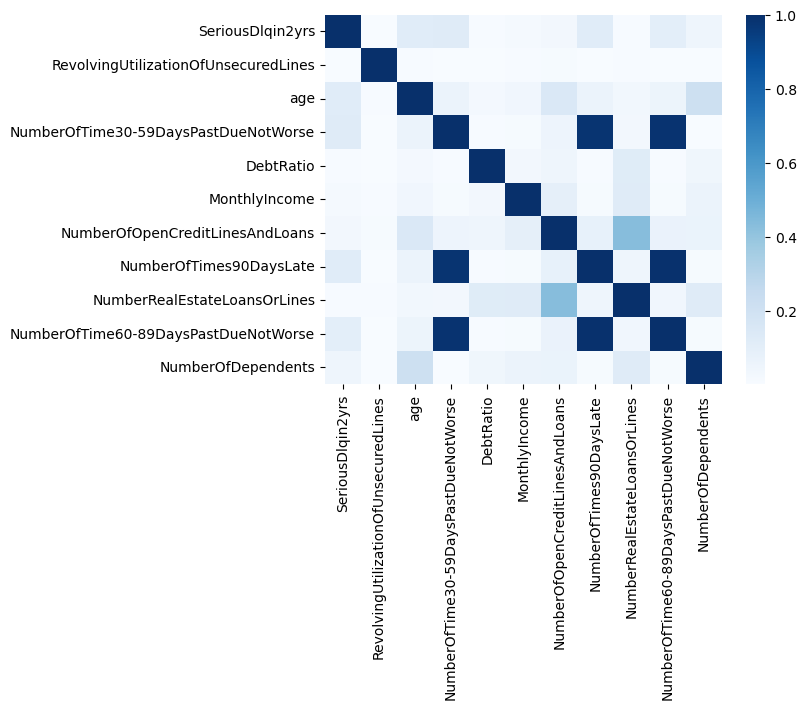

In [120]:
sns.heatmap(data=df.corr().abs(), cmap="Blues")

Es sorprendente que DebtRatio o RevolvingUtilization parece, a priori, no tener relación con los impagos.
Las variables de días de retraso son las más predictivas: Alguien que se ha retrasado tiene más probabilidades de dejar de pagar.